In [37]:
#task 1: Data Loading & Exploration
import pandas as pd

df = pd.read_csv("Reviews.csv")

df = df.head(5000)

print("First 10 rows of the dataset are:")
print(df.head(10))

print("Shape of dataset (rows, columns):\n")
print(df.shape)

print("Column names in dataset:\n")
print(df.columns)

print("The column containing review text is: 'Text' \n")

First 10 rows of the dataset are:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   
5   6  B006K2ZZ7K   ADT0SRK1MGOEU                   Twoapennything   
6   7  B006K2ZZ7K  A1SP2KVKFXXRU1                David C. Sullivan   
7   8  B006K2ZZ7K  A3JRGQVEQN31IQ               Pamela G. Williams   
8   9  B000E7L2R4  A1MZYO9TZK0BBI                         R. James   
9  10  B00171APVA  A21BT40VZCCYT4                    Carol A. Reed   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1 

In [38]:
#Task 2 — Data Cleaning

#Checking missing values in text column
df["Text"].isnull().sum()

#removing the null text
df=df.dropna(subset=["Text"])

#removing empty reviews
df=df[df["Text"].str.strip()!=""]

#Removing duplicate reviews
df=df.drop_duplicates(subset=["Text"])

#Keeping only needed columns
df=df[["Text","Score"]]

df=df.reset_index(drop=True)

df.head()
df.shape

(4984, 2)

In [41]:
#task 3: sentiment analysis

#testing the polarity of textblob

from textblob import TextBlob

TextBlob("this product is amazing").sentiment.polarity

0.6000000000000001

In [42]:
def get_sentiment(text):
    polarity=TextBlob(text).sentiment.polarity

    if polarity>0:
        return "Positive"
    elif polarity<0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"]=df["Text"].apply(get_sentiment)

df.head()

df["Sentiment"].value_counts()

Sentiment
Positive    4403
Negative     501
Neutral       80
Name: count, dtype: int64

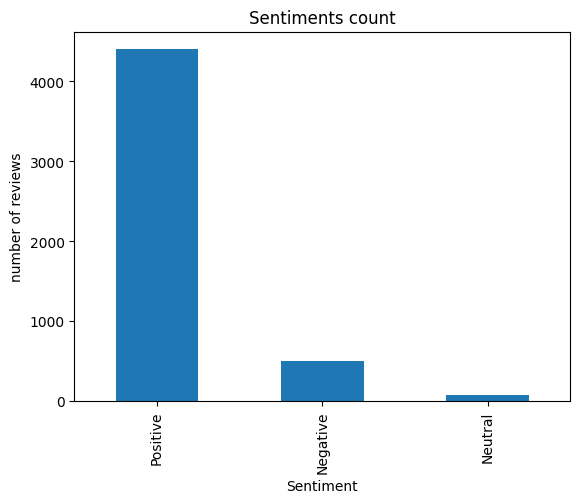

In [43]:
# task 4: Visualization

#1. Bar chart
import matplotlib.pyplot as plt

df["Sentiment"].value_counts()

df["Sentiment"].value_counts().plot(kind='bar')

plt.title("Sentiments count")

plt.xlabel("Sentiment")

plt.ylabel("number of reviews")

plt.show()

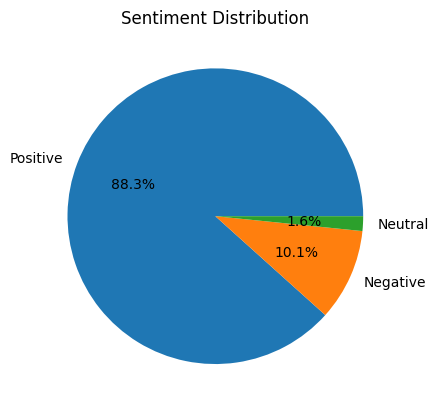

In [29]:
#2. pie chart
df["Sentiment"].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Sentiment Distribution")

plt.ylabel("")

plt.show()

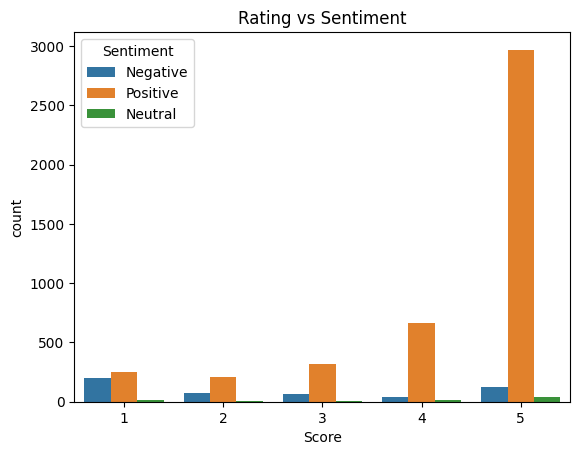

In [30]:
#3. Rating vs Sentiment chart
import seaborn as sns

sns.countplot(x="Score", hue="Sentiment", data=df)

plt.title("Rating vs Sentiment")

plt.show()

In [36]:
#task 5: analysing conclusion

total = len(df)
positive = df[df["Sentiment"] == "Positive"].shape[0]

percentage_positive = (positive / total) * 100
print(percentage_positive)

negative_reviews = df[df["Sentiment"] == "Negative"]
negative_reviews["Text"].head(10)


88.34269662921348


1     Product arrived labeled as Jumbo Salted Peanut...
14    The Strawberry Twizzlers are my guilty pleasur...
49    This oatmeal is not good. Its mushy, soft, I d...
51    This wasn't in stock the last time I looked. I...
61    Arrived in 6 days and were so stale i could no...
66    I purchased the Mango flavor, and to me it doe...
68    this was sooooo deliscious but too bad i ate e...
93    This is the same food we get at pet store. But...
97    My English Bulldog had skin allergies the summ...
98    I fed this to my Golden Retriever and he hated...
Name: Text, dtype: object

In [ ]:
#summary about the data
Out of all the analyzed reviews, approximately 88% of the reviews are positive, indicating that most customers are satisfied with the products.

From analyzing the negative reviews, customers mostly complain about poor taste, stale or low-quality products, and items not matching their expectations.
Some reviews also mention issues related to delivery or product availability.

One surprising observation was the very high number of positive reviews compared to negative ones, showing strong overall customer satisfaction.

Based on my findings, I recommended that the business should focus on improving product quality,freshness, and accurate product descriptions to reduce customer dissatisfaction.*/